In [1]:
import os
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)
os.makedirs('graphs', exist_ok=True)
os.makedirs('models', exist_ok=True)

print("PREDICTIVE MAINTENANCE PROJECT")

# Load the dataset
DATASET_PATH = "ai4i2020.csv"
if not os.path.exists(DATASET_PATH):
    print("\nERROR: ai4i2020.csv was not found.")
    print("Please place ai4i2020.csv inside the project folder.")
    exit()

df=pd.read_csv(DATASET_PATH)

print("\nDataset loaded successfully.")
print(f"Dataset shape: {df.shape}")

print("\nFirst 5 rows of the dataset:")
print(df.head())

print("\nDataset information:")
print(df.info())

print("\nMissing Value Check")
print(df.isnull().sum())

PREDICTIVE MAINTENANCE PROJECT

Dataset loaded successfully.
Dataset shape: (10000, 14)

First 5 rows of the dataset:
   UDI Product ID Type  Air temperature [K]  Process temperature [K]  \
0    1     M14860    M                298.1                    308.6   
1    2     L47181    L                298.2                    308.7   
2    3     L47182    L                298.1                    308.5   
3    4     L47183    L                298.2                    308.6   
4    5     L47184    L                298.2                    308.7   

   Rotational speed [rpm]  Torque [Nm]  Tool wear [min]  Machine failure  TWF  \
0                    1551         42.8                0                0    0   
1                    1408         46.3                3                0    0   
2                    1498         49.4                5                0    0   
3                    1433         39.5                7                0    0   
4                    1408         40.0      

In [2]:
print("STATISTICAL INFORMATION")
print(df.describe())

STATISTICAL INFORMATION
               UDI  Air temperature [K]  Process temperature [K]  \
count  10000.00000         10000.000000             10000.000000   
mean    5000.50000           300.004930               310.005560   
std     2886.89568             2.000259                 1.483734   
min        1.00000           295.300000               305.700000   
25%     2500.75000           298.300000               308.800000   
50%     5000.50000           300.100000               310.100000   
75%     7500.25000           301.500000               311.100000   
max    10000.00000           304.500000               313.800000   

       Rotational speed [rpm]   Torque [Nm]  Tool wear [min]  Machine failure  \
count            10000.000000  10000.000000     10000.000000     10000.000000   
mean              1538.776100     39.986910       107.951000         0.033900   
std                179.284096      9.968934        63.654147         0.180981   
min               1168.000000      3.80

In [3]:
print("DATASET RANGES")

numeric_columns = df.select_dtypes(include=np.number).columns

for column in numeric_columns:
    print(
        f"{column}: "
        f"Minimum = {df[column].min():.2f}, "
        f"Maximum = {df[column].max():.2f}, "
        f"Mean = {df[column].mean():.2f}, "
        f"Variance = {df[column].var():.2f}"
    )

DATASET RANGES
UDI: Minimum = 1.00, Maximum = 10000.00, Mean = 5000.50, Variance = 8334166.67
Air temperature [K]: Minimum = 295.30, Maximum = 304.50, Mean = 300.00, Variance = 4.00
Process temperature [K]: Minimum = 305.70, Maximum = 313.80, Mean = 310.01, Variance = 2.20
Rotational speed [rpm]: Minimum = 1168.00, Maximum = 2886.00, Mean = 1538.78, Variance = 32142.79
Torque [Nm]: Minimum = 3.80, Maximum = 76.60, Mean = 39.99, Variance = 99.38
Tool wear [min]: Minimum = 0.00, Maximum = 253.00, Mean = 107.95, Variance = 4051.85
Machine failure: Minimum = 0.00, Maximum = 1.00, Mean = 0.03, Variance = 0.03
TWF: Minimum = 0.00, Maximum = 1.00, Mean = 0.00, Variance = 0.00
HDF: Minimum = 0.00, Maximum = 1.00, Mean = 0.01, Variance = 0.01
PWF: Minimum = 0.00, Maximum = 1.00, Mean = 0.01, Variance = 0.01
OSF: Minimum = 0.00, Maximum = 1.00, Mean = 0.01, Variance = 0.01
RNF: Minimum = 0.00, Maximum = 1.00, Mean = 0.00, Variance = 0.00


In [4]:
type_mapping = {
    "L":0, "M":1,"H":2 }
df["Type"]=df["Type"].map(type_mapping)

print("\nMachine Type Encoding:")
print("L = 0")
print("M = 1")
print("H = 2")


Machine Type Encoding:
L = 0
M = 1
H = 2


In [5]:
features = [
    "Type",
    "Air temperature [K]",
    "Process temperature [K]",
    "Rotational speed [rpm]",
    "Torque [Nm]",
    "Tool wear [min]"
]

target = "Machine failure"

x = df[features]
y = df[target]

x_train, x_test, y_train, y_test = train_test_split(
    x,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("\nTraining samples:", len(x_train))
print("Testing samples:", len(x_test))


Training samples: 8000
Testing samples: 2000


In [6]:
models = {

    "Logistic Regression": Pipeline([
        ("scaler", StandardScaler()),
        ("model", LogisticRegression(max_iter=1000))
    ]),

    "Random Forest": RandomForestClassifier(
        n_estimators=200,
        random_state=42
    ),

    "SVM": Pipeline([
        ("scaler", StandardScaler()),
        ("model", SVC(
            probability=True,
            random_state=42
        ))
    ])
}

In [7]:
results = []

trained_models = {}


print("MODEL TRAINING")

for name, model in models.items():

    print(f"\nTraining {name}...")

    model.fit(x_train, y_train)

    y_pred = model.predict(x_test)

    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(
        y_test,
        y_pred,
        zero_division=0
    )
    recall = recall_score(
        y_test,
        y_pred,
        zero_division=0
    )
    f1 = f1_score(
        y_test,
        y_pred,
        zero_division=0
    )

    results.append({
        "Model": name,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1 Score": f1
    })

    trained_models[name] = model

    print("Accuracy :", round(accuracy, 4))
    print("Precision:", round(precision, 4))
    print("Recall   :", round(recall, 4))
    print("F1 Score :", round(f1, 4))

MODEL TRAINING

Training Logistic Regression...
Accuracy : 0.9675
Precision: 0.6364
Recall   : 0.1029
F1 Score : 0.1772

Training Random Forest...
Accuracy : 0.9845
Precision: 0.8776
Recall   : 0.6324
F1 Score : 0.735

Training SVM...


C:\Users\user\anaconda3\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(


Accuracy : 0.972
Precision: 0.875
Recall   : 0.2059
F1 Score : 0.3333


In [8]:
results_df = pd.DataFrame(results)

print("MODEL COMPARISON")

print(results_df)

MODEL COMPARISON
                 Model  Accuracy  Precision    Recall  F1 Score
0  Logistic Regression    0.9675   0.636364  0.102941  0.177215
1        Random Forest    0.9845   0.877551  0.632353  0.735043
2                  SVM    0.9720   0.875000  0.205882  0.333333


In [9]:
best_model_name = results_df.loc[
    results_df["F1 Score"].idxmax(),
    "Model"
]

best_model = trained_models[best_model_name]

print("\nBest model based on F1 Score:")
print(best_model_name)


Best model based on F1 Score:
Random Forest


In [11]:
y_pred_best = best_model.predict(x_test)

print("CLASSIFICATION REPORT")

print(
    classification_report(
        y_test,
        y_pred_best,
        zero_division=0
    )
)

CLASSIFICATION REPORT
              precision    recall  f1-score   support

           0       0.99      1.00      0.99      1932
           1       0.88      0.63      0.74        68

    accuracy                           0.98      2000
   macro avg       0.93      0.81      0.86      2000
weighted avg       0.98      0.98      0.98      2000



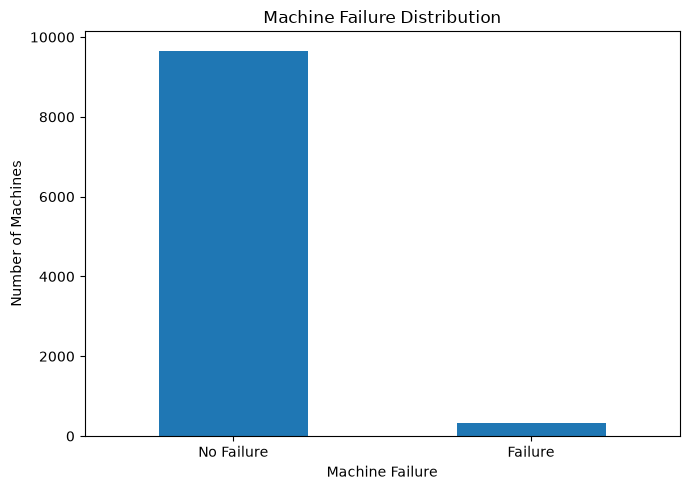

In [13]:
plt.figure(figsize=(7, 5))

df[target].value_counts().sort_index().plot(
    kind="bar"
)

plt.title("Machine Failure Distribution")
plt.xlabel("Machine Failure")
plt.ylabel("Number of Machines")
plt.xticks(
    [0, 1],
    ["No Failure", "Failure"],
    rotation=0
)

plt.tight_layout()
plt.savefig("graphs/failure_distribution.png")

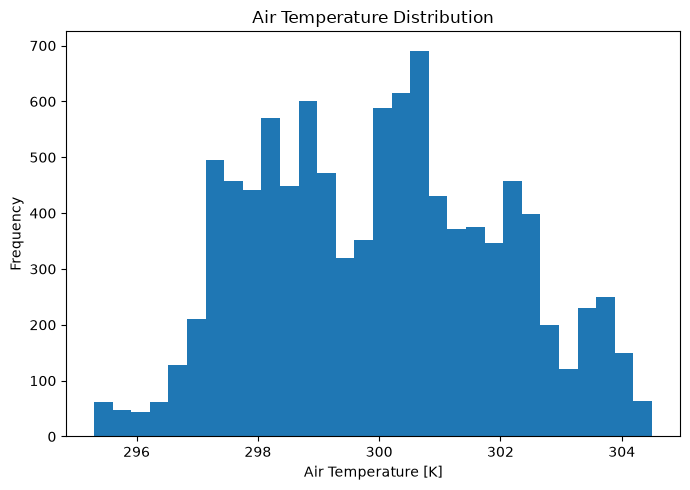

In [24]:
plt.figure(figsize=(7, 5))

plt.hist(
    df["Air temperature [K]"],
    bins=30
)

plt.title("Air Temperature Distribution")
plt.xlabel("Air Temperature [K]")
plt.ylabel("Frequency")

plt.tight_layout()
plt.savefig("graphs/air_temperature_distribution.png")

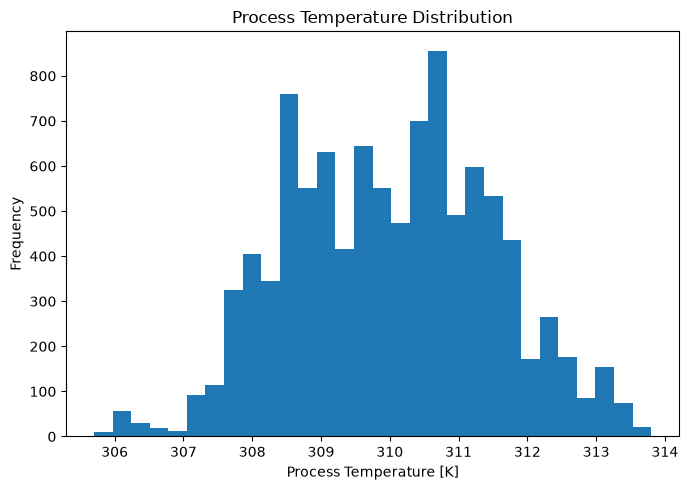

In [25]:
plt.figure(figsize=(7, 5))

plt.hist(
    df["Process temperature [K]"],
    bins=30
)

plt.title("Process Temperature Distribution")
plt.xlabel("Process Temperature [K]")
plt.ylabel("Frequency")

plt.tight_layout()
plt.savefig("graphs/process_temperature_distribution.png")

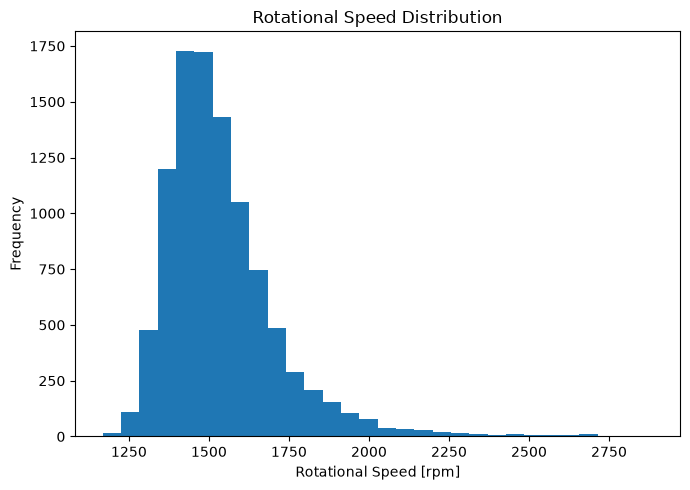

In [26]:
plt.figure(figsize=(7, 5))

plt.hist(
    df["Rotational speed [rpm]"],
    bins=30
)

plt.title("Rotational Speed Distribution")
plt.xlabel("Rotational Speed [rpm]")
plt.ylabel("Frequency")

plt.tight_layout()
plt.savefig("graphs/rotational_speed_distribution.png")

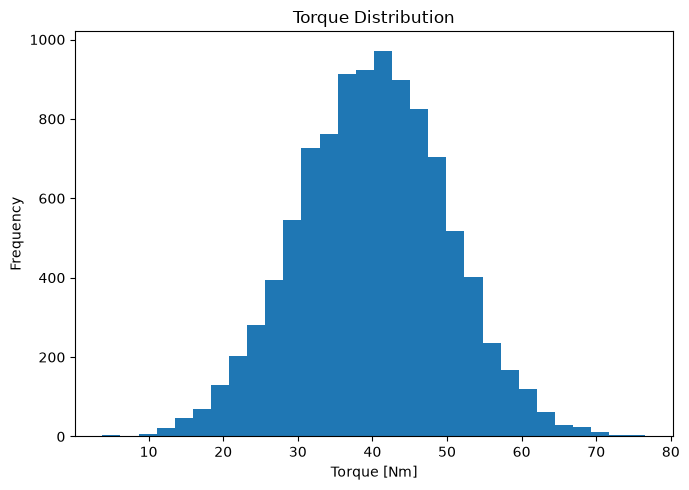

In [27]:
plt.figure(figsize=(7, 5))

plt.hist(
    df["Torque [Nm]"],
    bins=30
)

plt.title("Torque Distribution")
plt.xlabel("Torque [Nm]")
plt.ylabel("Frequency")

plt.tight_layout()
plt.savefig("graphs/torque_distribution.png")

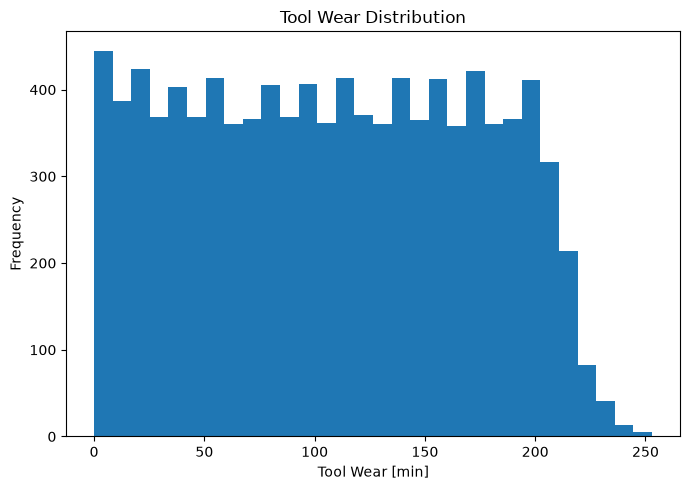

In [28]:
plt.figure(figsize=(7, 5))

plt.hist(
    df["Tool wear [min]"],
    bins=30
)

plt.title("Tool Wear Distribution")
plt.xlabel("Tool Wear [min]")
plt.ylabel("Frequency")

plt.tight_layout()
plt.savefig("graphs/tool_wear_distribution.png")

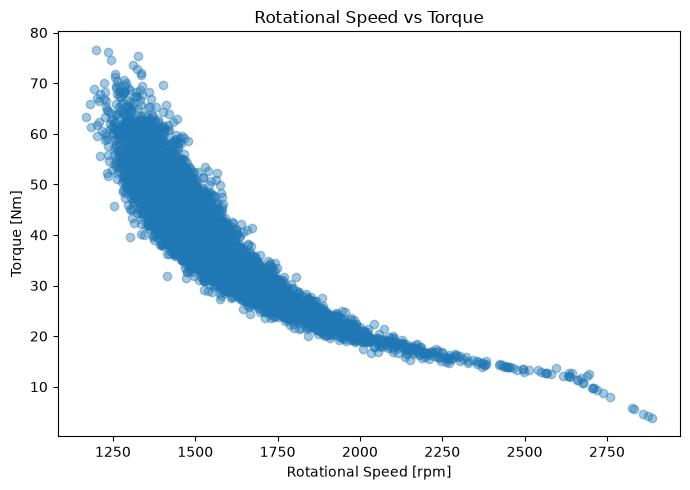

In [29]:
plt.figure(figsize=(7, 5))

plt.scatter(
    df["Rotational speed [rpm]"],
    df["Torque [Nm]"],
    alpha=0.4
)

plt.title("Rotational Speed vs Torque")
plt.xlabel("Rotational Speed [rpm]")
plt.ylabel("Torque [Nm]")

plt.tight_layout()
plt.savefig("graphs/speed_vs_torque.png")

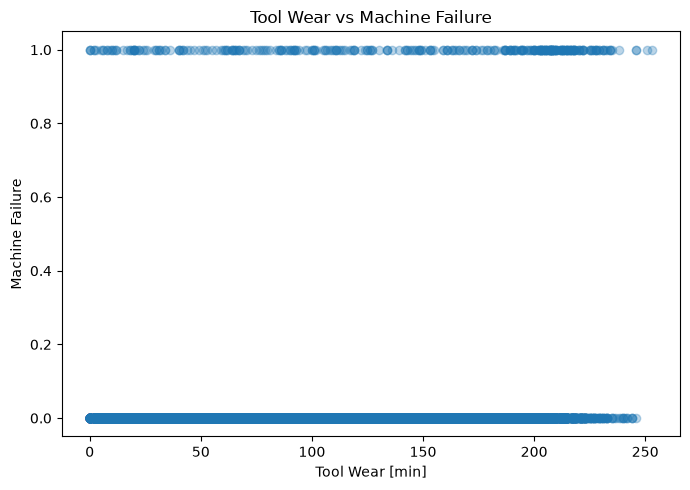

In [30]:
plt.figure(figsize=(7, 5))

plt.scatter(
    df["Tool wear [min]"],
    df["Machine failure"],
    alpha=0.3
)

plt.title("Tool Wear vs Machine Failure")
plt.xlabel("Tool Wear [min]")
plt.ylabel("Machine Failure")

plt.tight_layout()
plt.savefig("graphs/tool_wear_vs_failure.png")

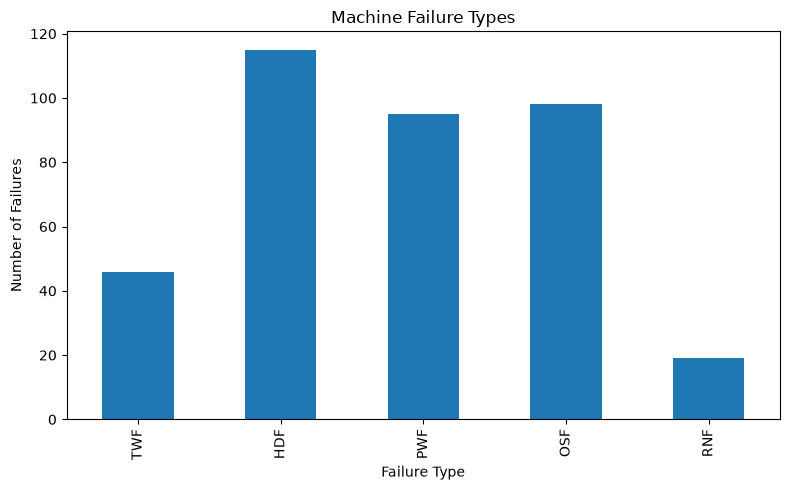

In [31]:
failure_columns = [
    "TWF",
    "HDF",
    "PWF",
    "OSF",
    "RNF"
]

failure_counts = df[failure_columns].sum()

plt.figure(figsize=(8, 5))

failure_counts.plot(kind="bar")

plt.title("Machine Failure Types")
plt.xlabel("Failure Type")
plt.ylabel("Number of Failures")

plt.tight_layout()
plt.savefig("graphs/failure_types.png")

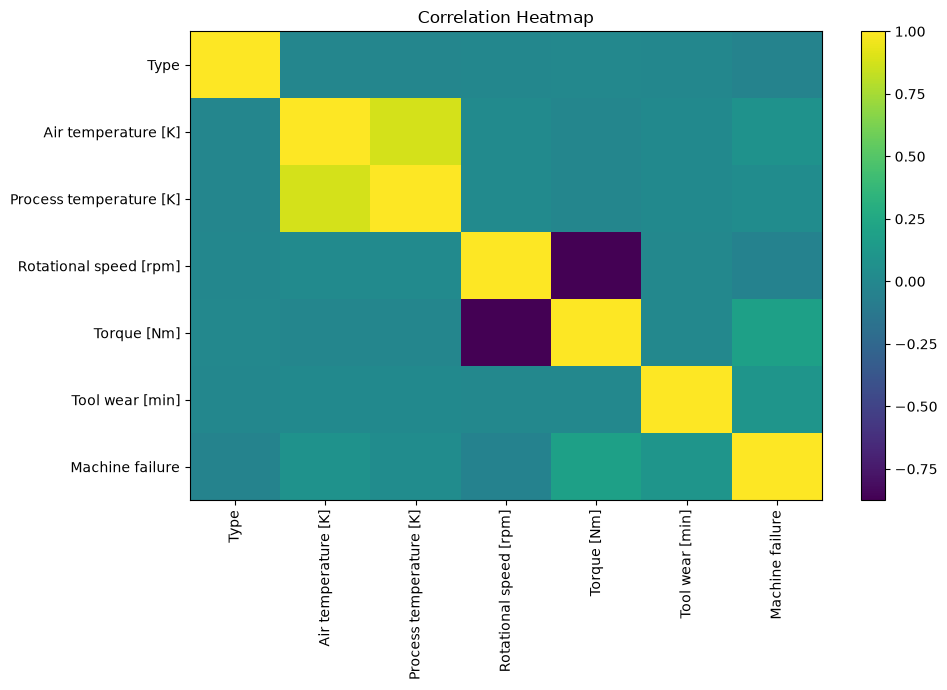

In [32]:
plt.figure(figsize=(10, 7))

correlation = df[
    [
        "Type",
        "Air temperature [K]",
        "Process temperature [K]",
        "Rotational speed [rpm]",
        "Torque [Nm]",
        "Tool wear [min]",
        "Machine failure"
    ]
].corr()

plt.imshow(
    correlation,
    interpolation="nearest",
    aspect="auto"
)

plt.colorbar()

plt.xticks(
    range(len(correlation.columns)),
    correlation.columns,
    rotation=90
)

plt.yticks(
    range(len(correlation.columns)),
    correlation.columns
)

plt.title("Correlation Heatmap")

plt.tight_layout()
plt.savefig("graphs/correlation_heatmap.png")

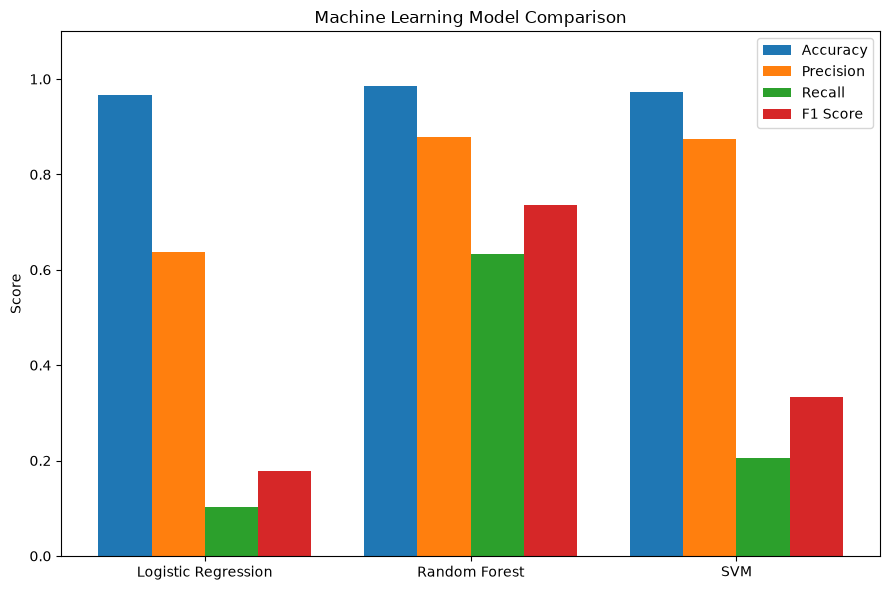

In [33]:
plt.figure(figsize=(9, 6))

x = np.arange(len(results_df))
width = 0.2

plt.bar(
    x - width,
    results_df["Accuracy"],
    width,
    label="Accuracy"
)

plt.bar(
    x,
    results_df["Precision"],
    width,
    label="Precision"
)

plt.bar(
    x + width,
    results_df["Recall"],
    width,
    label="Recall"
)

plt.bar(
    x + 2 * width,
    results_df["F1 Score"],
    width,
    label="F1 Score"
)

plt.xticks(
    x + width / 2,
    results_df["Model"]
)

plt.ylabel("Score")
plt.title("Machine Learning Model Comparison")
plt.ylim(0, 1.1)
plt.legend()

plt.tight_layout()
plt.savefig("graphs/model_comparison.png")

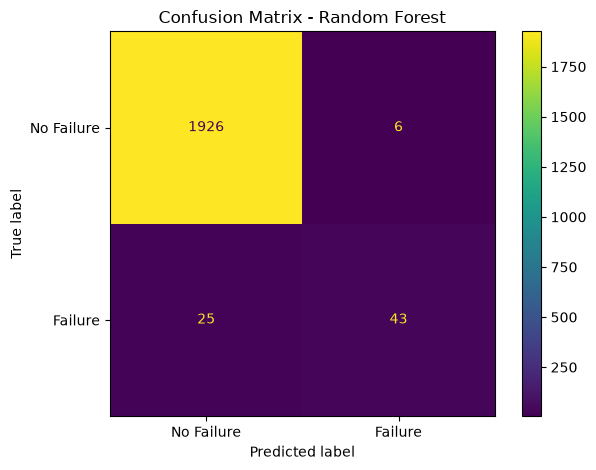

In [34]:
cm = confusion_matrix(
    y_test,
    y_pred_best
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["No Failure", "Failure"]
)

disp.plot()

plt.title(
    f"Confusion Matrix - {best_model_name}"
)

plt.tight_layout()
plt.savefig("graphs/confusion_matrix.png")

In [35]:
rf_model = trained_models["Random Forest"]

importance = rf_model.feature_importances_

feature_importance_df = pd.DataFrame({
    "Feature": features,
    "Importance": importance
}).sort_values(
    by="Importance",
    ascending=False
)
print("FEATURE IMPORTANCE")
print(feature_importance_df)

FEATURE IMPORTANCE
                   Feature  Importance
4              Torque [Nm]    0.331058
3   Rotational speed [rpm]    0.223159
5          Tool wear [min]    0.163673
1      Air temperature [K]    0.129297
2  Process temperature [K]    0.127044
0                     Type    0.025770


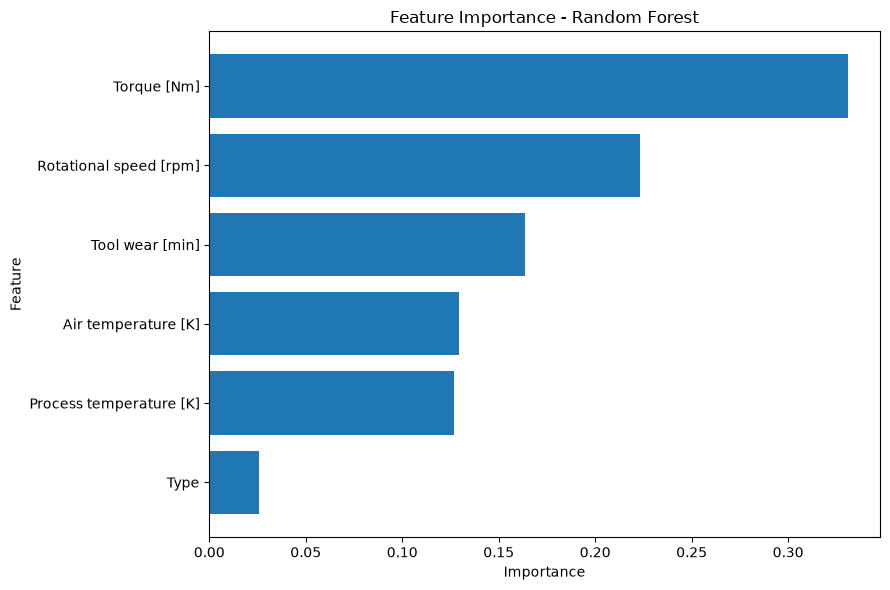

In [36]:
plt.figure(figsize=(9, 6))

plt.barh(
    feature_importance_df["Feature"],
    feature_importance_df["Importance"]
)

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Feature Importance - Random Forest")

plt.gca().invert_yaxis()

plt.tight_layout()
plt.savefig("graphs/feature_importance.png")

In [38]:
model_path = "models/predictive_maintenance_model.pkl"

with open(model_path, "wb") as file:
    pickle.dump(best_model, file)

print("\nBest model saved successfully:")
print(model_path)


Best model saved successfully:
models/predictive_maintenance_model.pkl


In [42]:
def maintenance_recommendation(failure_probability, tool_wear, air_temperature, process_temperature, torque, rotational_speed):
    warnings = []
    temperature_difference = process_temperature - air_temperature

    # Temperature warning
    if temperature_difference > 10:
        warnings.append("High temperature difference detected.")

    # Torque warning
    if torque > 50:
        warnings.append("High torque detected.")

    # Speed warning
    if rotational_speed < 1200:
        warnings.append("Low rotational speed detected.")

    # Tool wear
    if tool_wear >= 200:
        warnings.append("Critical tool wear.")
    elif tool_wear >= 150:
        warnings.append("High tool wear.")
    elif tool_wear >= 100:
        warnings.append("Moderate tool wear.")

    # Maintenance recommendation
    if failure_probability >= 0.75 or tool_wear >= 200:
        status = "IMMEDIATE MAINTENANCE REQUIRED"
        estimated_hours = 0
    elif failure_probability >= 0.50 or tool_wear >= 150:
        status = "MAINTENANCE REQUIRED SOON"
        estimated_hours = 10
    elif failure_probability >= 0.25 or tool_wear >= 100:
        status = "MAINTENANCE SHOULD BE SCHEDULED"
        estimated_hours = 25
    else:
        status = "MACHINE CONDITION NORMAL"
        estimated_hours = 50

    return status, estimated_hours, warnings


In [43]:
print("MACHINE SENSOR INPUT")
print("\nEnter machine sensor values.")

try:

    machine_type = input(
        "\nMachine Type (L/M/H): "
    ).upper()

    if machine_type not in ["L", "M", "H"]:
        machine_type = "M"

    type_value = type_mapping[machine_type]

    air_temperature = float(
        input("Air Temperature [K]: ")
    )

    process_temperature = float(
        input("Process Temperature [K]: ")
    )

    rotational_speed = float(
        input("Rotational Speed [rpm]: ")
    )

    torque = float(
        input("Torque [Nm]: ")
    )

    tool_wear = float(
        input("Tool Wear [min]: ")
    )

    sensor_data = pd.DataFrame(
        [[
            type_value,
            air_temperature,
            process_temperature,
            rotational_speed,
            torque,
            tool_wear
        ]],
        columns=features
    )

    prediction = best_model.predict(
        sensor_data
    )[0]

    probability = best_model.predict_proba(
        sensor_data
    )[0][1]

    status, estimated_hours, warnings = (
        maintenance_recommendation(
            probability,
            tool_wear,
            air_temperature,
            process_temperature,
            torque,
            rotational_speed
        )
    )


    print("PREDICTION RESULT")
    if prediction == 1:
        print("Machine Failure: YES")
    else:
        print("Machine Failure: NO")

    print(
        "Failure Probability:",
        round(probability * 100, 2),
        "%"
    )

    print("Maintenance Status:", status)

    if estimated_hours == 0:
        print(
            "Estimated Maintenance Time: IMMEDIATE"
        )
    else:
        print(
            "Estimated Maintenance Time:",
            estimated_hours,
            "operating hours"
        )

    print("\nSensor Warnings:")

    if len(warnings) == 0:
        print("No major warning detected.")
    else:
        for warning in warnings:
            print("-", warning)


except ValueError:

    print(
        "\nInvalid sensor value entered."
    )




MACHINE SENSOR INPUT

Enter machine sensor values.



Machine Type (L/M/H):  m
Air Temperature [K]:  303
Process Temperature [K]:  398
Rotational Speed [rpm]:  900
Torque [Nm]:  37
Tool Wear [min]:  93


PREDICTION RESULT
Machine Failure: NO
Failure Probability: 24.0 %
Maintenance Status: MACHINE CONDITION NORMAL
Estimated Maintenance Time: 50 operating hours

Sensor Warnings:
- High temperature difference detected.
- Low rotational speed detected.


In [44]:
print("PROJECT EXECUTION COMPLETED")
print("\nGenerated folders:")
print("1. graphs/")
print("2. model/")

print("\nGenerated model:")
print("model/predictive_maintenance_model.pkl")

print("\nThe Streamlit dashboard can now be started using:")
print("streamlit run dashboard.py")

PROJECT EXECUTION COMPLETED

Generated folders:
1. graphs/
2. model/

Generated model:
model/predictive_maintenance_model.pkl

The Streamlit dashboard can now be started using:
streamlit run dashboard.py
